In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<Axes: xlabel='Month'>

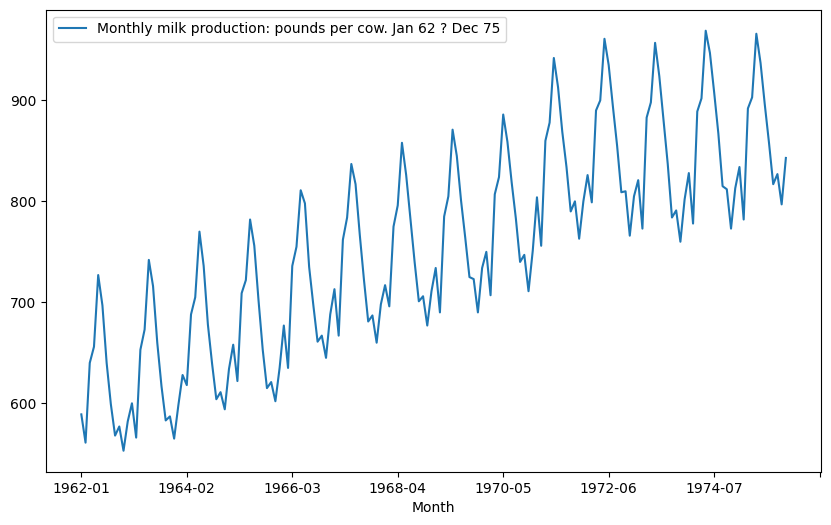

In [7]:
df = pd.read_csv('/content/monthly-milk-production-pounds.csv',index_col='Month',parse_dates=True)

df.index.freq='MS'
df.head()
df.plot(figsize=(10,6))

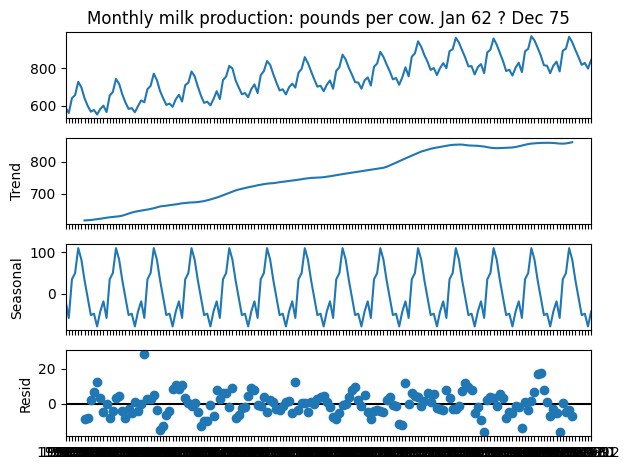

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Drop any missing values before seasonal decomposition
df_cleaned = df['Monthly milk production: pounds per cow. Jan 62 ? Dec 75'].dropna()

results = seasonal_decompose(df_cleaned, period=12)
results.plot()
len(df_cleaned)
train = df_cleaned.iloc[:156]
test = df_cleaned.iloc[156:]

In [13]:
df.head()

,Monthly milk production: pounds per cow. Jan 62 ? Dec 75
Month,
1962-01,589.0
1962-02,561.0
1962-03,640.0
1962-04,656.0
1962-05,727.0


In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df.head(),df.tail()
scaler.fit(train.values.reshape(-1, 1))
scaled_train = scaler.transform(train.values.reshape(-1, 1))
scaled_test = scaler.transform(test.values.reshape(-1, 1))
scaled_train[:10]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231]])

In [21]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
n_input = 3
n_features = 1

generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)
print(len(scaled_train),len(generator))

156 153


In [23]:
# The original line 'from numpy.random.mtrand import f x,y = generator[0]' caused a SyntaxError.
# The 'f' import was likely unintended or misplaced, and the assignment needs to be on its own line.
x,y = generator[0]

# The original line had two print statements on one line.
# Also, 'x.flatten' should likely be 'x.flatten()' to get the flattened array.
print(f'Given the Array: \n{x.flatten()}')
print(f'Predict this y: \n {y}')

# The original line 'x.shape n_input = 12' contained two statements.
# 'x.shape' on its own doesn't produce output unless printed or assigned.
# If you wish to see the shape, you can uncomment: print(x.shape)
n_input = 12 # This line updates n_input

# This recreates the generator with the new n_input
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

Given the Array: 
[0.08653846 0.01923077 0.20913462]
Predict this y: 
 [[0.24759615]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0438
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0229
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0173
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0116
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0095
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0069
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0040
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0043
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0041
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0038
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0035
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0041
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0042
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0045
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step 

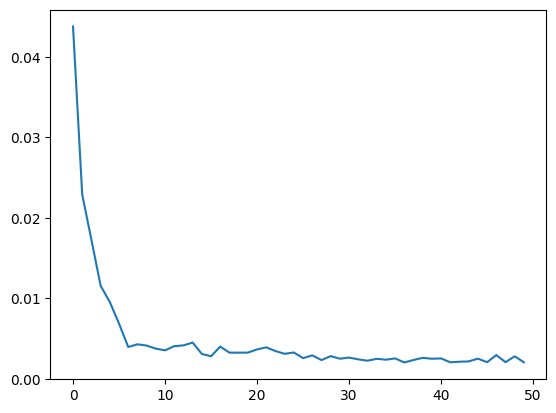

In [25]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()
model.fit(generator, epochs=50)

loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)

In [27]:
last_train_batch = scaled_train[-12:]
last_train_batch = last_train_batch.reshape(1, n_input, n_features)
model.predict(last_train_batch)
scaled_test[0]
test_predictions = []
first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
RMSE: 27.58308711475301


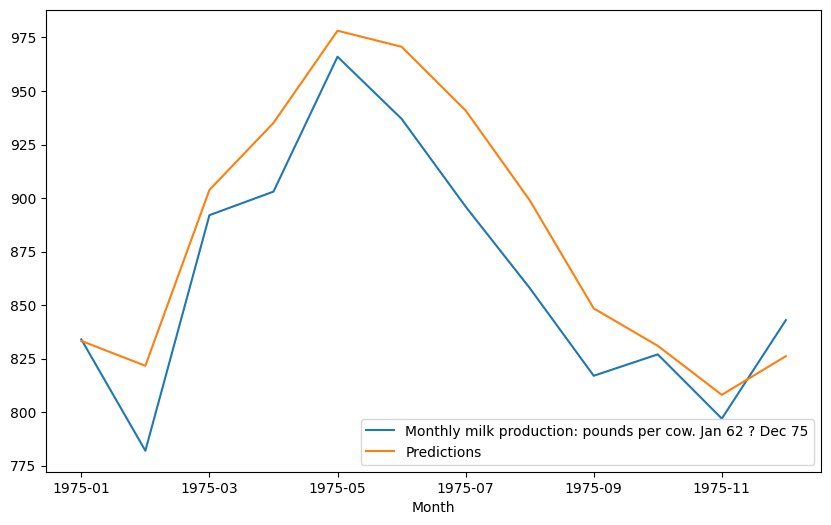

In [29]:
for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

# Invert scaling for predictions
true_predictions = scaler.inverse_transform(test_predictions)

# Convert test Series to DataFrame to add 'Predictions' column
test_df = pd.DataFrame(test)
test_df['Predictions'] = true_predictions

test_df.plot(figsize=(10,6))

from sklearn.metrics import mean_squared_error
from math import sqrt

# Calculate RMSE, using the original column from test_df for true values
rmse = sqrt(mean_squared_error(test_df[test_df.columns[0]], test_df['Predictions']))
print(f"RMSE: {rmse}")